# Project - Movies Rating Prediction
---

## Import libraries

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random as rnd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, root_mean_squared_error

## Data loading
---

In [2]:
"""This dataset is in format: column1::column2::column3. Therefore,
 I will use seperator as double colon(::) here 
for splitting my dataset into 3 columns, set default engine C 
 to engine python for handling this split and set default encoding
 UTF 8 to latin-1 for this dataset."""

df_movie = pd.read_csv(r"D:\Shubham\Python ML\Movie Rating Dataset\movies.dat",
                       sep= '::', engine='python', encoding="latin-1")
df_movie.columns = ['Movie_ids','Movie_name','Category']
df_movie.dropna(inplace=True)
df_movie.head()

,Movie_ids,Movie_name,Category
0,2,Jumanji (1995),Adventure|Children's|Fantasy
1,3,Grumpier Old Men (1995),Comedy|Romance
2,4,Waiting to Exhale (1995),Comedy|Drama
3,5,Father of the Bride Part II (1995),Comedy
4,6,Heat (1995),Action|Crime|Thriller


In [3]:
# For rating dataset
df_rating = pd.read_csv(r"D:\Shubham\Python ML\Movie Rating Dataset\ratings.dat",
                       sep= '::', engine='python', encoding="latin-1")
df_rating.columns = ['ID','MovieID','Ratings','TimeStamp']
df_rating.dropna(inplace=True)
df_rating.head()

,ID,MovieID,Ratings,TimeStamp
0,1,661,3,978302109
1,1,914,3,978301968
2,1,3408,4,978300275
3,1,2355,5,978824291
4,1,1197,3,978302268


In [4]:
# For users dataset
df_user = pd.read_csv(r"D:\Shubham\Python ML\Movie Rating Dataset\users.dat",
                       sep= '::', engine='python', encoding="latin-1")
df_user.columns = ['User_id','Gender','Age','Occupation','Zip-code']
df_user.dropna(inplace=True)
df_user.head()

,User_id,Gender,Age,Occupation,Zip-code
0,2,M,56,16,70072
1,3,M,25,15,55117
2,4,M,45,7,02460
3,5,M,25,20,55455
4,6,F,50,9,55117


In [5]:
# Combine the datasets
df = pd.concat([df_movie,df_rating,df_user], axis=1)
df.head()

,Movie_ids,Movie_name,Category,ID,MovieID,Ratings,TimeStamp,User_id,Gender,Age,Occupation,Zip-code
0,2.0,Jumanji (1995),Adventure|Children's|Fantasy,1,661,3,978302109,2.0,M,56.0,16.0,70072
1,3.0,Grumpier Old Men (1995),Comedy|Romance,1,914,3,978301968,3.0,M,25.0,15.0,55117
2,4.0,Waiting to Exhale (1995),Comedy|Drama,1,3408,4,978300275,4.0,M,45.0,7.0,02460
3,5.0,Father of the Bride Part II (1995),Comedy,1,2355,5,978824291,5.0,M,25.0,20.0,55455
4,6.0,Heat (1995),Action|Crime|Thriller,1,1197,3,978302268,6.0,F,50.0,9.0,55117


## EDA
---

In [13]:
def age_bucket(x):
    if x < 18:
        return "Under 18"
    elif 18 <= x <= 24:
        return "18-24"
    elif 25 <= x <= 34:
        return "25-34"
    elif 35 <= x <= 44:
        return "35-44"
    elif 45 <= x <= 49:
        return "45-49"
    elif 50 <= x <= 55:
        return "50-55"
    else:
        return "56+"
    
df.loc[df['Age'].notnull(), 'age_category'] = df.loc[df['Age'].notnull(), 'Age'].apply(age_bucket)
   

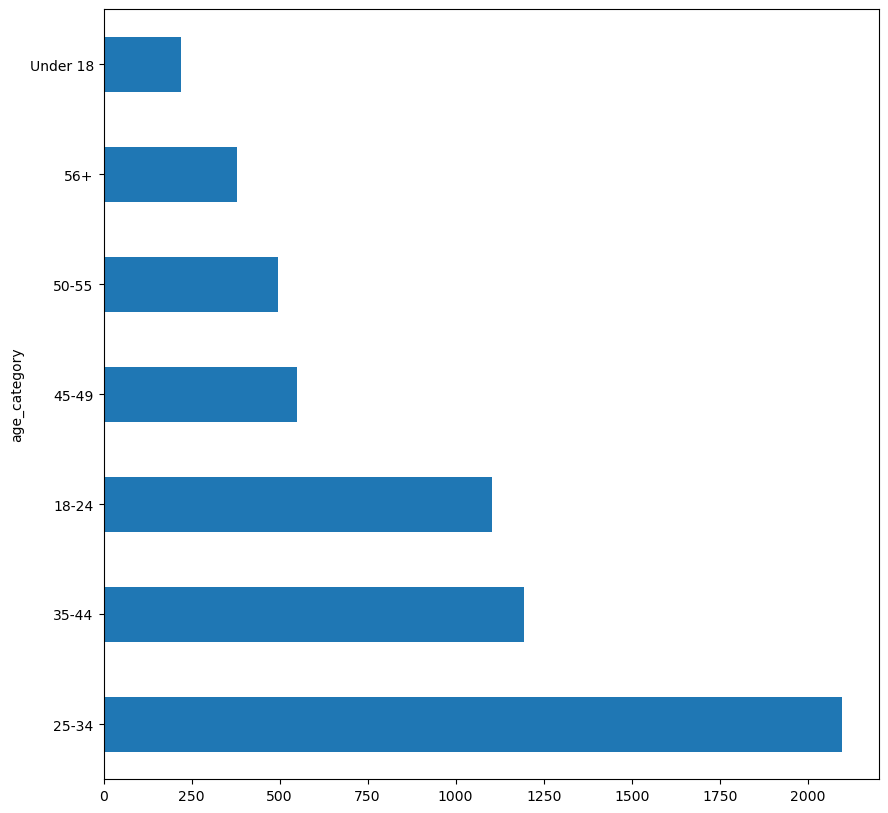

In [15]:
df['age_category'].value_counts().plot(kind='barh', figsize=(10,10))
plt.show()

People in the range of `Age` 25-34 contributes more in this dataset.

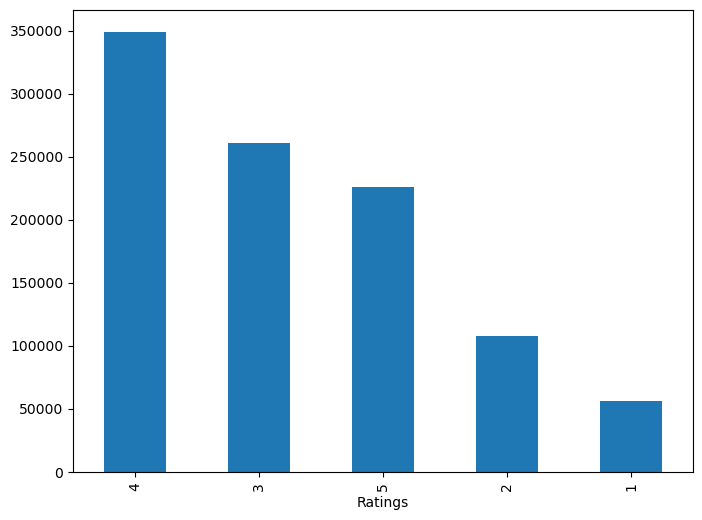

In [18]:
df['Ratings'].value_counts().plot(kind='bar',figsize=(8,6))
plt.show()

More positive ratings (>4) as compare to negative ratings(<2).

## Model building
---

In [24]:
df_top_500 = df.head(500)
df_top_500.drop(['Age'],axis=1,inplace=True)
df_top_500.head()


C:\Users\Bhawna\AppData\Local\Temp\ipykernel_13320\3784452624.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_top_500.drop(['Age'],axis=1,inplace=True)


,Movie_ids,Movie_name,Category,ID,MovieID,Ratings,TimeStamp,User_id,Gender,Occupation,Zip-code,age_category
0,2.0,Jumanji (1995),Adventure|Children's|Fantasy,1,661,3,978302109,2.0,M,16.0,70072,56+
1,3.0,Grumpier Old Men (1995),Comedy|Romance,1,914,3,978301968,3.0,M,15.0,55117,25-34
2,4.0,Waiting to Exhale (1995),Comedy|Drama,1,3408,4,978300275,4.0,M,7.0,02460,45-49
3,5.0,Father of the Bride Part II (1995),Comedy,1,2355,5,978824291,5.0,M,20.0,55455,25-34
4,6.0,Heat (1995),Action|Crime|Thriller,1,1197,3,978302268,6.0,F,9.0,55117,50-55


In [27]:
features = df_top_500[['User_id','Gender','age_category','Occupation','Category']]
target = df_top_500['Ratings']

# Encode categorical features
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

X = encoder.fit_transform(features)
y = target


In [29]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
## Logistic Regression
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

rmse_lr = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse_lr)


RMSE: 1.3856406460551018


In [53]:
## Support Vector Machines
svm = SVC()
svm.fit(x_train, y_train)
y_pred = svm.predict(x_test)
rmse_svm = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse_svm)


RMSE: 1.2609520212918492


In [54]:
## K Nearest Neighbors
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)

rmse_knn = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse_knn)

RMSE: 1.6643316977093239


In [55]:
## Decision Tree Classifier
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
y_pred = dt.predict(x_test)
rmse_dt = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse_dt)

RMSE: 1.4106735979665885


In [56]:
## Random Forest Classifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
rmse_rf = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse_rf)

RMSE: 1.3228756555322954


## Model comparison
---

In [58]:
models = pd.DataFrame({
    "model":['Logistic Regression', 'Support Vector Machines','K Nearest Neighbors',
             'Decision Tree Classifier','Random Forest Classifier'],
    "Score":[rmse_lr, rmse_svm, rmse_knn, rmse_dt, rmse_rf]
})
models.sort_values(by='Score', ascending=True)

,model,Score
1,Support Vector Machines,1.260952
4,Random Forest Classifier,1.322876
0,Logistic Regression,1.385641
3,Decision Tree Classifier,1.410674
2,K Nearest Neighbors,1.664332


`SVM` performs best among other models.